# Lecture 4 — Backpropagation

**CMU 10-414/714, Deep Learning Systems**
Companion notebook · Sangram Lembe

The hypothesis class is now a network, so the only thing left is its gradient. This notebook
derives it in code for a two-layer network, generalises to $L$ layers, verifies both against
finite differences, and then trains an MLP on digits.

It is also the last time in this series that a gradient is computed by hand. Lecture 5 replaces
all of it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

np.random.seed(0)
digits = load_digits()
X_all, y_all = digits.data / 16.0, digits.target.astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=0, stratify=y_all)
m, n = X_train.shape
k = int(y_all.max() + 1)

def softmax_rows(logits):
    Z = np.exp(logits - logits.max(1, keepdims=True))
    return Z / Z.sum(1, keepdims=True)

def one_hot(y, k):
    I = np.zeros((y.size, k)); I[np.arange(y.size), y] = 1
    return I

def cross_entropy(logits, y):
    mx = logits.max(1, keepdims=True)
    lse = mx[:, 0] + np.log(np.exp(logits - mx).sum(1))
    return float(np.mean(lse - logits[np.arange(y.size), y]))

print(f"n = {n}, k = {k}, m = {m}")

n = 64, k = 10, m = 1347


## 1. The two-layer gradients

With $S = \mathrm{softmax}(h_\theta(X))$, the same quantity called $Z$ in lecture 2 and renamed
because $Z_i$ now means a layer:

$$\nabla_{W_2}\, \ell = \sigma(X W_1)^{\mathsf{T}} (S - I_y)$$

$W_2$ is easy: everything before it is constant, so this is the lecture 2 result with
$\sigma(XW_1)$ playing the role of the input.

$W_1$ requires passing through the nonlinearity. The scalar-pretence factors are
$(S - I_y)$, $W_2$, $\sigma'(XW_1)$ and $X$, with shapes $m\times k$, $d\times k$, $m\times d$,
$m\times n$ — and the answer must be $n \times d$. The only $n$ lives in $X$, so
$X^{\mathsf{T}}$ leads, and whatever follows must be $m \times d$. Two candidates are already
that shape, so the only way to combine them is elementwise:

$$\nabla_{W_1}\, \ell = X^{\mathsf{T}}\!\left[(S - I_y) W_2^{\mathsf{T}} \circ \sigma'(X W_1)\right]$$

In [2]:
def two_layer_loss_and_grads(X, y, W1, W2):
    """Forward pass, loss, and the gradients for both weight matrices."""
    A1 = X @ W1                 # (m, d) pre-activation
    Z1 = np.maximum(0, A1)      # (m, d) hidden layer, ReLU
    logits = Z1 @ W2            # (m, k)

    loss = cross_entropy(logits, y)

    S  = softmax_rows(logits)               # (m, k)
    G  = (S - one_hot(y, k)) / y.size       # (m, k) adjoint at the top

    dW2 = Z1.T @ G                          # (d, m) @ (m, k) -> (d, k)
    dZ1 = G @ W2.T                          # (m, k) @ (k, d) -> (m, d)
    dA1 = dZ1 * (A1 > 0)                    # elementwise: the ReLU derivative
    dW1 = X.T @ dA1                         # (n, m) @ (m, d) -> (n, d)
    return loss, dW1, dW2

In [3]:
def grad_check(fn_loss, params, eps=1e-5):
    """Two-sided finite differences for every entry of every parameter."""
    numeric = []
    for p in params:
        g = np.zeros_like(p)
        for idx in np.ndindex(*p.shape):
            old = p[idx]
            p[idx] = old + eps; a = fn_loss()
            p[idx] = old - eps; b = fn_loss()
            p[idx] = old
            g[idx] = (a - b) / (2 * eps)
        numeric.append(g)
    return numeric

# Small, deliberately unequal shapes: with n == d == k a wrong transpose hides.
Xs, ys = X_train[:16], y_train[:16]
W1 = np.random.randn(n, 7) * 0.3
W2 = np.random.randn(7, k) * 0.3

_, dW1, dW2 = two_layer_loss_and_grads(Xs, ys, W1, W2)
nW1, nW2 = grad_check(lambda: two_layer_loss_and_grads(Xs, ys, W1, W2)[0], [W1, W2])

print("max |analytic - numeric|  W1:", np.abs(dW1 - nW1).max())
print("max |analytic - numeric|  W2:", np.abs(dW2 - nW2).max())
assert max(np.abs(dW1 - nW1).max(), np.abs(dW2 - nW2).max()) < 1e-7
print("\nboth gradients verified")

max |analytic - numeric|  W1: 4.1106954645764304e-11
max |analytic - numeric|  W2: 3.0947688856031164e-11

both gradients verified


That check is not optional. Nothing in the derivation *proved* the elementwise product was
right — shape matching merely permitted it. The finite-difference agreement is the evidence.

## 2. The $L$-layer case: name the repeated term

Expanding $\nabla_{W_i}\ell$ by the chain rule gives a long product whose leading factors are
shared across every layer. Give that shared prefix a name — the **adjoint**:

$$G_i \equiv \nabla_{Z_i}\, \ell, \qquad \text{shape } m \times n_i$$

and two expressions fall out, sharing a factor:

$$G_i = \left[G_{i+1} \circ \sigma'(Z_i W_i)\right] W_i^{\mathsf{T}}, \qquad
\nabla_{W_i}\, \ell = Z_i^{\mathsf{T}} \left[G_{i+1} \circ \sigma'(Z_i W_i)\right]$$

That is backpropagation: the chain rule plus caching of intermediate results.

In [4]:
def forward(X, Ws):
    """Run the network, keeping every layer. Z[i] is Z_{i+1} in the notes."""
    Z = [X]
    for i, W in enumerate(Ws):
        A = Z[-1] @ W                                    # (m, n_{i+1})
        # last layer is linear so the network emits logits
        Z.append(np.maximum(0, A) if i < len(Ws) - 1 else A)
    return Z

def backward(Z, Ws, y):
    """All parameter gradients from one cached forward pass."""
    G = (softmax_rows(Z[-1]) - one_hot(y, k)) / y.size   # G_{L+1}
    dWs = [None] * len(Ws)
    for i in reversed(range(len(Ws))):
        # apply sigma' first; the final layer has no nonlinearity
        D = G if i == len(Ws) - 1 else G * (Z[i] @ Ws[i] > 0)
        dWs[i] = Z[i].T @ D                              # (n_i, m) @ (m, n_{i+1})
        G = D @ Ws[i].T                                  # (m, n_i), pass it down
    return dWs

def net_loss(X, y, Ws):
    return cross_entropy(forward(X, Ws)[-1], y)

In [5]:
# Verify on a 4-layer network with all widths different.
Ws = [np.random.randn(n, 11) * 0.3,
      np.random.randn(11, 9) * 0.3,
      np.random.randn(9,  7) * 0.3,
      np.random.randn(7,  k) * 0.3]

analytic = backward(forward(Xs, Ws), Ws, ys)
numeric  = grad_check(lambda: net_loss(Xs, ys, Ws), Ws)

for i, (a, b) in enumerate(zip(analytic, numeric)):
    diff = np.abs(a - b).max()
    print(f"layer {i+1}  shape {str(a.shape):>9}  max diff {diff:.3e}")
    assert diff < 1e-7
print("\nL-layer backprop verified")

layer 1  shape  (64, 11)  max diff 3.971e-11
layer 2  shape   (11, 9)  max diff 3.211e-11
layer 3  shape    (9, 7)  max diff 3.742e-11
layer 4  shape   (7, 10)  max diff 4.388e-11

L-layer backprop verified


## 3. The memory cost

Look at `backward`: it reads `Z[i]`. The parameter gradient needs both $G_{i+1}$ *and* $Z_i$, so
the forward pass cannot discard its intermediates. If you only wanted the output you could
overwrite $Z_i$ as soon as $Z_{i+1}$ existed — here you cannot.

That is the central trade-off: gradients for every parameter at roughly twice the cost of one
forward pass, paid for in memory.

In [6]:
Ws_big = [np.random.randn(n, 256), np.random.randn(256, 256), np.random.randn(256, k)]
Z = forward(X_train, Ws_big)

params = sum(W.size for W in Ws_big)
cached = sum(z.size for z in Z)
print(f"parameters stored            : {params:>12,} floats")
print(f"activations cached (m={X_train.shape[0]}) : {cached:>12,} floats")
print(f"ratio                        : {cached/params:>12.1f}x")
print("\nActivations scale with batch size; parameters do not.")
print("This is why batch size is the first thing you cut when you run out of memory.")

parameters stored            :       84,480 floats
activations cached (m=1347) :      789,342 floats
ratio                        :          9.3x

Activations scale with batch size; parameters do not.
This is why batch size is the first thing you cut when you run out of memory.


## 4. Training the network

Same loss, same optimizer as lecture 2. Only the hypothesis class changed — which was the whole
claim of this lecture.

softmax regression  test error: 0.0333
two-layer network   test error: 0.0222


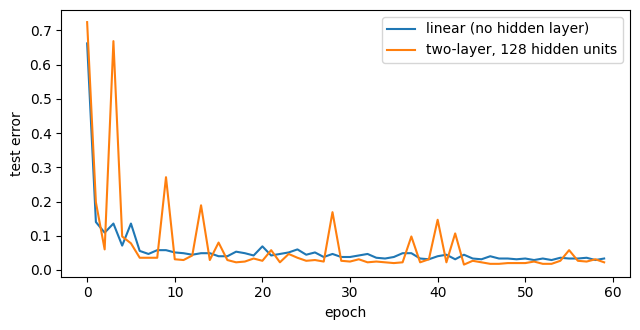

In [7]:
def train_mlp(sizes, lr=0.5, B=64, epochs=60, seed=0):
    rng = np.random.default_rng(seed)
    # He-style scaling: variance 2/fan_in keeps activations from vanishing
    Ws = [rng.normal(0, np.sqrt(2.0 / a), (a, b)) for a, b in zip(sizes[:-1], sizes[1:])]
    err = lambda X, y: float((np.argmax(forward(X, Ws)[-1], 1) != y).mean())
    hist = []
    for _ in range(epochs):
        order = rng.permutation(X_train.shape[0])
        for i in range(0, X_train.shape[0], B):
            idx = order[i:i+B]
            for W, g in zip(Ws, backward(forward(X_train[idx], Ws), Ws, y_train[idx])):
                W -= lr * g
        hist.append((err(X_train, y_train), err(X_test, y_test)))
    return Ws, hist

_, hist_mlp = train_mlp([n, 128, k])
_, hist_lin = train_mlp([n, k])          # no hidden layer = softmax regression

print(f"softmax regression  test error: {hist_lin[-1][1]:.4f}")
print(f"two-layer network   test error: {hist_mlp[-1][1]:.4f}")

plt.figure(figsize=(6.5, 3.4))
plt.plot([h[1] for h in hist_lin], label="linear (no hidden layer)")
plt.plot([h[1] for h in hist_mlp], label="two-layer, 128 hidden units")
plt.xlabel("epoch"); plt.ylabel("test error"); plt.legend()
plt.tight_layout(); plt.show()

## Summary

- $\nabla_{W_2}\ell = \sigma(XW_1)^{\mathsf{T}}(S - I_y)$; $\nabla_{W_1}\ell$ needs an elementwise $\sigma'$ term that shape matching permits but does not prove — hence the gradient check.
- For $L$ layers, name the shared prefix $G_i$ and the recursion is two lines.
- Backprop is the chain rule plus caching. The cached activations, not the parameters, are what fill your memory.
- Swapping the hypothesis class for a network is the only change; loss and optimizer are untouched.

This derivation was already unpleasant for a plain MLP, and it would have to be redone for every
new architecture. Lecture 5 removes the need entirely.